In [321]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

In [322]:
# Data
x_train = pd.read_csv("../data/x_train_final.csv")
y_train = pd.read_csv("../data/y_train_final.csv")
x_test = pd.read_csv("../data/x_test_final.csv")

In [323]:
x_train

,Unnamed: 0.1,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
0,0,0,VBXNMF,KYF,2023-04-03,8,0.0,0.0,1.0,-3.0,-1.0,-2.0
1,1,1,VBXNMF,JLR,2023-04-03,9,0.0,0.0,0.0,1.0,0.0,1.0
2,2,2,VBXNMF,EOH,2023-04-03,10,-1.0,0.0,0.0,-1.0,0.0,0.0
3,3,3,VBXNMF,VXY,2023-04-03,11,-1.0,-1.0,0.0,2.0,-2.0,0.0
4,4,4,VBXNMF,OCB,2023-04-03,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
667259,667259,667259,BFNJJK,DGG,2023-11-10,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0
667260,667260,667260,BFNJJK,KDN,2023-11-10,23,0.0,0.0,-1.0,1.0,0.0,0.0
667261,667261,667261,BFNJJK,TVD,2023-11-10,24,1.0,0.0,0.0,-1.0,-3.0,-1.0
667262,667262,667262,BFNJJK,TXP,2023-11-10,26,2.0,2.0,1.0,0.0,0.0,1.0


In [324]:
y_train

,Unnamed: 0,p0q0
0,0,-1.0
1,1,-1.0
2,2,-1.0
3,3,1.0
4,4,3.0
...,...,...
667259,667259,1.0
667260,667260,2.0
667261,667261,2.0
667262,667262,1.0


## Feature Engineering

In [325]:
def fit_features(train_df: pd.DataFrame) -> dict:
    df = train_df.copy()
    df["date"] = pd.to_datetime(df["date"])

    cols_retard = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]

    mappings = {
        "freq_gare": df["gare"].value_counts(normalize=True),
        "retard_moyen_gare": df.groupby("gare")[cols_retard].mean().mean(axis=1),
    }
    return mappings


def transform_features(df: pd.DataFrame, mappings: dict) -> pd.DataFrame:
    df = df.copy()

    # Outliers
    df.loc[df["p0q3"] <= -500, "p0q3"] = (df["p0q2"] + df["p0q4"]) / 2
    df.loc[df["p0q4"] <= -500, "p0q4"] = (df["p0q2"] + df["p0q3"]) / 2
    
    
    # Date
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month
    df["day_of_week"] = df["date"].dt.dayofweek

    # Encodage cyclique
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["day_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["day_of_week_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

    # Frequency encoding gare (depuis le train set)
    df["encoded_gare"] = df["gare"].map(mappings["freq_gare"]).fillna(0)


    # Features agrégées
    df["somme_retard_prev_trains"] = df["p2q0"] + df["p3q0"] + df["p4q0"]
    df["somme_retard_prev_gares"] = df["p0q2"] + df["p0q3"] + df["p0q4"]

    # Retard moyen par gare (depuis le train set)
    df["retard_moyen_gare"] = df["gare"].map(mappings["retard_moyen_gare"]).fillna(0)

    # Nombre d'arrêts par train/date
    df["nb_arrets"] = df.groupby(["train", "date"])["arret"].transform("count")
    
    # Tendances trains
    df["diff_retard_trains"] = df["p2q0"] - df["p4q0"]  # tendance du retard
    df["max_retard_train"] = df[["p2q0","p3q0","p4q0"]].max(axis=1)
    df["min_retard_train"] = df[["p2q0","p3q0","p4q0"]].min(axis=1)
    df["std_retard_train"] = df[["p2q0","p3q0","p4q0"]].std(axis=1)
    df["mean_retard_train"] = df[["p2q0","p3q0","p4q0"]].mean(axis=1)
    
    df["diff_retard_gares"] = df["p0q2"] - df["p0q4"]   # tendance à la gare
    df["max_retard_gare"] = df[["p0q2","p0q3","p0q4"]].max(axis=1)
    df["min_retard_gare"] = df[["p0q2","p0q3","p0q4"]].min(axis=1)
    df["std_retard_gare"] = df[["p0q2","p0q3","p0q4"]].std(axis=1)
    df["mean_retard_gare"] = df[["p0q2","p0q3","p0q4"]].mean(axis=1)

    

    # Drop colonnes inutiles
    cols_to_drop = ["Unnamed: 0.1", "Unnamed: 0", "date", "day_of_week", "month", "gare", "train"]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df

In [326]:
# Fit sur train, transform sur train et test
mappings_train = fit_features(x_train)
mappings_test = fit_features(x_test)
x_train_fe = transform_features(x_train, mappings_train)
x_test_fe = transform_features(x_test, mappings_test)

In [327]:
x_train_fe

,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,month_sin,month_cos,day_of_week_sin,...,diff_retard_trains,max_retard_train,min_retard_train,std_retard_train,mean_retard_train,diff_retard_gares,max_retard_gare,min_retard_gare,std_retard_gare,mean_retard_gare
0,8,0.0,0.0,1.0,-3.0,-1.0,-2.0,0.866025,-0.500000,0.000000,...,-1.0,1.0,0.0,0.57735,0.333333,-1.0,-1.0,-3.0,1.000000,-2.000000
1,9,0.0,0.0,0.0,1.0,0.0,1.0,0.866025,-0.500000,0.000000,...,0.0,0.0,0.0,0.00000,0.000000,0.0,1.0,0.0,0.577350,0.666667
2,10,-1.0,0.0,0.0,-1.0,0.0,0.0,0.866025,-0.500000,0.000000,...,-1.0,0.0,-1.0,0.57735,-0.333333,-1.0,0.0,-1.0,0.577350,-0.333333
3,11,-1.0,-1.0,0.0,2.0,-2.0,0.0,0.866025,-0.500000,0.000000,...,-1.0,0.0,-1.0,0.57735,-0.666667,2.0,2.0,-2.0,2.000000,0.000000
4,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0,0.866025,-0.500000,0.000000,...,0.0,-1.0,-1.0,0.00000,-1.000000,-3.0,3.0,-1.0,2.081666,1.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667259,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0,-0.500000,0.866025,-0.433884,...,6.0,0.0,-6.0,3.21455,-2.333333,1.0,0.0,-2.0,1.000000,-1.000000
667260,23,0.0,0.0,-1.0,1.0,0.0,0.0,-0.500000,0.866025,-0.433884,...,1.0,0.0,-1.0,0.57735,-0.333333,1.0,1.0,0.0,0.577350,0.333333
667261,24,1.0,0.0,0.0,-1.0,-3.0,-1.0,-0.500000,0.866025,-0.433884,...,1.0,1.0,0.0,0.57735,0.333333,0.0,-1.0,-3.0,1.154701,-1.666667
667262,26,2.0,2.0,1.0,0.0,0.0,1.0,-0.500000,0.866025,-0.433884,...,1.0,2.0,1.0,0.57735,1.666667,-1.0,1.0,0.0,0.577350,0.333333


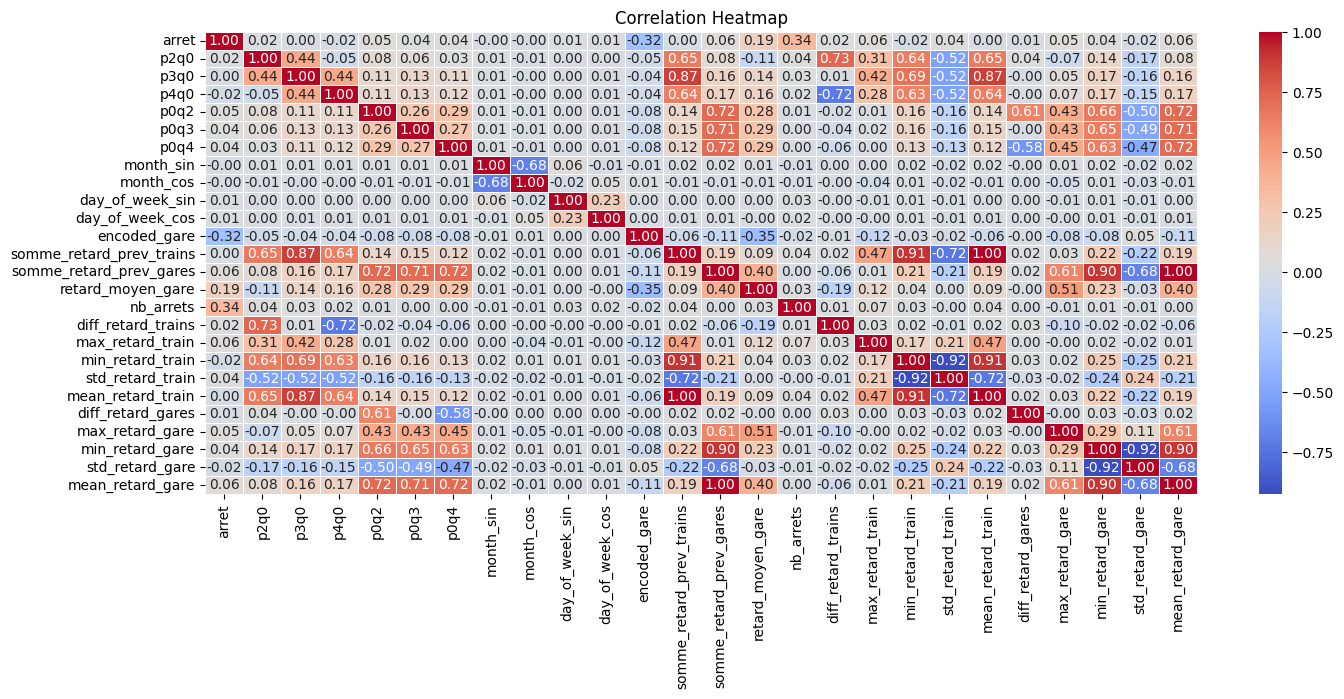

In [328]:
matrix = x_train_fe.corr()
plt.figure(figsize=(16,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [329]:
x_test_fe

,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,month_sin,month_cos,day_of_week_sin,...,diff_retard_trains,max_retard_train,min_retard_train,std_retard_train,mean_retard_train,diff_retard_gares,max_retard_gare,min_retard_gare,std_retard_gare,mean_retard_gare
0,12,0.0,0.0,-2.0,-4.0,-2.0,-4.0,-5.000000e-01,0.866025,0.000000,...,2.0,0.0,-2.0,1.154701,-0.666667,0.0,-2.0,-4.0,1.154701,-3.333333
1,12,0.0,0.0,-1.0,1.0,-1.0,0.0,-5.000000e-01,0.866025,0.000000,...,1.0,0.0,-1.0,0.577350,-0.333333,1.0,1.0,-1.0,1.000000,0.000000
2,12,0.0,1.0,-1.0,1.0,-1.0,1.0,-5.000000e-01,0.866025,0.000000,...,1.0,1.0,-1.0,1.000000,0.000000,0.0,1.0,-1.0,1.154701,0.333333
3,12,0.0,0.0,-1.0,-1.0,0.0,-1.0,-5.000000e-01,0.866025,0.000000,...,1.0,0.0,-1.0,0.577350,-0.333333,0.0,0.0,-1.0,0.577350,-0.666667
4,12,1.0,-2.0,0.0,0.0,0.0,0.0,-5.000000e-01,0.866025,0.000000,...,1.0,1.0,-2.0,1.527525,-0.333333,0.0,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20652,24,-1.0,-1.0,1.0,0.0,1.0,0.0,-2.449294e-16,1.000000,-0.433884,...,-2.0,1.0,-1.0,1.154701,-0.333333,0.0,1.0,0.0,0.577350,0.333333
20653,12,0.0,0.0,0.0,0.0,0.0,0.0,-2.449294e-16,1.000000,-0.433884,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000
20654,18,1.0,-2.0,0.0,-1.0,-1.0,-2.0,-2.449294e-16,1.000000,-0.433884,...,1.0,1.0,-2.0,1.527525,-0.333333,1.0,-1.0,-2.0,0.577350,-1.333333
20655,24,-2.0,-2.0,1.0,0.0,0.0,1.0,-2.449294e-16,1.000000,-0.433884,...,-3.0,1.0,-2.0,1.732051,-1.000000,-1.0,1.0,0.0,0.577350,0.333333


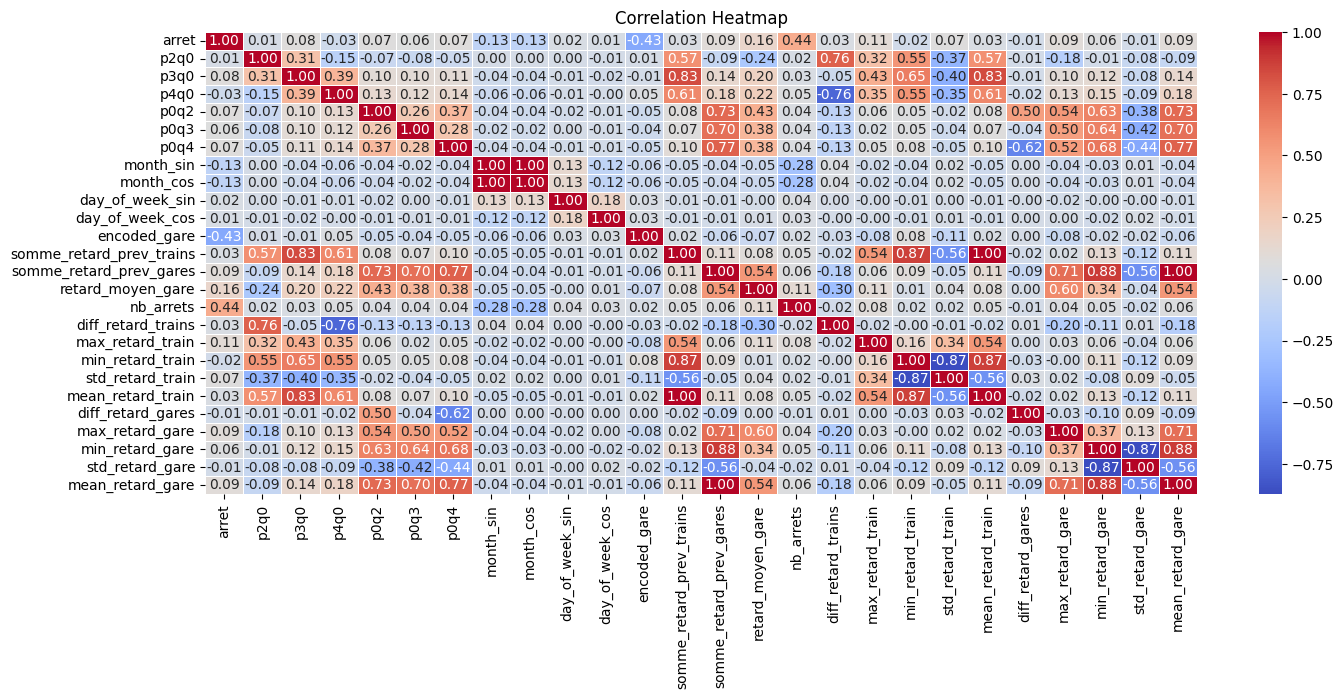

In [330]:
matrix = x_test_fe.corr()
plt.figure(figsize=(16,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Modeles

In [334]:
import lightgbm as lgb

SEED = 42

kf = KFold(n_splits=5, shuffle=False)

oof_preds = np.zeros(len(x_train_fe))
test_preds = np.zeros(len(x_test_fe))
fold_scores = []

X = x_train_fe
X_test = x_test_fe
y = y_train.drop(columns=["Unnamed: 0"])["p0q0"]

# Paramètres LightGBM
lgb_params = {
    "n_estimators": 5000,
    "learning_rate": 0.01,
    "max_depth": -1,
    "num_leaves": 64,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": SEED,
    "n_jobs": -1,
    
}

print(f"Entraînement en {kf.n_splits} folds...")
print("─" * 60)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(**lgb_params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)],
        
    )

    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred
    test_preds += model.predict(X_test) / kf.n_splits

    score = mean_absolute_error(y_val, val_pred)
    fold_scores.append(score)
    print(f"  Fold {fold} | MAE = {score:.4f}")

print("─" * 60)
oof_score = mean_absolute_error(y, oof_preds)
print(f"  OOF global        | MAE = {oof_score:.4f}")
print(f"  Moyenne des folds | MAE = {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

Entraînement en 5 folds...
────────────────────────────────────────────────────────────
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[470]	valid_0's l1: 0.667361	valid_0's l2: 1.68805
  Fold 1 | MAE = 0.6674
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[404]	valid_0's l1: 0.748465	valid_0's l2: 2.26291
  Fold 2 | MAE = 0.7485
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[971]	valid_0's l1: 0.930249	valid_0's l2: 3.326
  Fold 3 | MAE = 0.9302
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[405]	valid_0's l1: 0.767262	valid_0's l2: 5.0377
  Fold 4 | MAE = 0.7673
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[296]	valid_0's l1: 0.746912	valid_0's l2: 3.73565
  Fold 5 | MAE = 0.7469
───────────────────────────────────────────────────────

## Optimisation Optuna

## Ré-entrainement avec paramètres optimaux

In [151]:
xgb_params = study.best_params
xgb_params["n_estimators"] = 5000
xgb_params["tree_method"] = "gpu_hist"
xgb_params["random_state"] = SEED




kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

y = y_train.drop(columns=["Unnamed: 0"])["p0q0"].values

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):

    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    model = xgb.XGBRegressor(**xgb_params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    # OOF
    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred

    
    test_preds += model.predict(X_test) / kf.n_splits
    

print('─' * 60)
oof_score = mean_absolute_error(y, oof_preds)

print(f"MAE : {oof_score}")

────────────────────────────────────────────────────────────
MAE : 0.7144815681644409


In [152]:
# soumission
submission = pd.DataFrame({
    'p0q0': test_preds
}, index=x_test.index)



oof_str = f"{oof_score:.4f}"

filename = f"../output/y_test_predictions_MAE_{oof_str}.csv"


print(f'Nombre de prédictions : {len(submission)}')
print(f'Valeurs manquantes    : {submission.isnull().sum().sum()}')
print(f'Min prédit            : {submission["p0q0"].min():.4f}')
print(f'Max prédit            : {submission["p0q0"].max():.4f}')
print(f'Moyenne prédite       : {submission["p0q0"].mean():.4f}')



submission.to_csv(filename)



print(f'\nFichier sauvegardé : {filename} ✓')
display(submission.head(10))

Nombre de prédictions : 20657
Valeurs manquantes    : 0
Min prédit            : -34.8538
Max prédit            : 2.1561
Moyenne prédite       : -1.1020

Fichier sauvegardé : ../output/y_test_predictions_MAE_0.7145.csv ✓


,p0q0
0,-0.882241
1,-0.714805
2,-1.485607
3,-0.754559
4,-0.720316
5,-0.942193
6,-0.846753
7,-0.119552
8,-0.644754
9,-0.997463
